In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [23]:
# System configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
input_size = 28      # Width of one row (28 pixels)
sequence_length = 28 # Height of the image (28 rows total)
hidden_size = 128    # Number of features in the RNN hidden state
num_layers = 2       # Number of stacked RNN layers
num_classes = 10     # Digits 0 to 9
batch_size = 64
epochs = 3

In [24]:
# Image transformations (convert to tensor and normalize pixel values)
transform = transforms.Compose([
    transforms.ToTensor(),     # for rgb channel=3, for minst grayscale image channel=1   3D shape=(1,28,28)
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load datasets
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

# Initialize DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)  # DataLoader adds a brand-new Batch Size dimension at the very front (index 0)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)  # shape becomes 4D shape becomes (64, 1, 28, 28)

## Build RNN

In [25]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(RNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Use LSTM for better sequence memory than basic RNN
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully connected layer to map hidden state to 10 output classes
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        # Initial hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        
        # Forward pass through LSTM
        # out shape: (batch_size, sequence_length, hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        
        # Decode the hidden state of the very last time step (row 28)
        out = self.fc(out[:, -1, :])
        return out


In [26]:
# Instantiate model
model = RNN(input_size, hidden_size, num_layers, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## Train the RNN

In [27]:
# PyTorch enforces this 4D standard ([Batch, Channels, Height, Width]) because Convolutional Neural Networks (CNNs) strictly require it.
# torchvision is built entirely around computer vision standards. To maintain structural consistency across all image-based tasks, it automatically forces every image dataset into a 4D layout, even if the image is grayscale and lacks color depth.

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    
    
    for Xb, yb in train_loader:
        optimizer.zero_grad()

        # Moving your data to a GPU using .to(device) can speed up your training loop by 10x to 100x.
        Xb = Xb.squeeze(1).to(device) # add singleton direction  #  "undo" that default vision formatting(4D -> 3D) by running squeeze(1)
        
        outputs = model(Xb) # (batch_size, 10)

        loss = criterion(outputs, yb)   # compute loss
        loss.backward() # backprop
        optimizer.step()  # weights update

        running_loss += loss.item()

    print(f"epoch = {epoch+1}/{epochs} and loss = {running_loss/len(train_loader)}")
        

epoch = 1/3 and loss = 0.3177014494370391
epoch = 2/3 and loss = 0.07718169452227366
epoch = 3/3 and loss = 0.055202554937686395


## Evaluation

accuracy = 98.61999999999999
accuracy_score: 0.9862


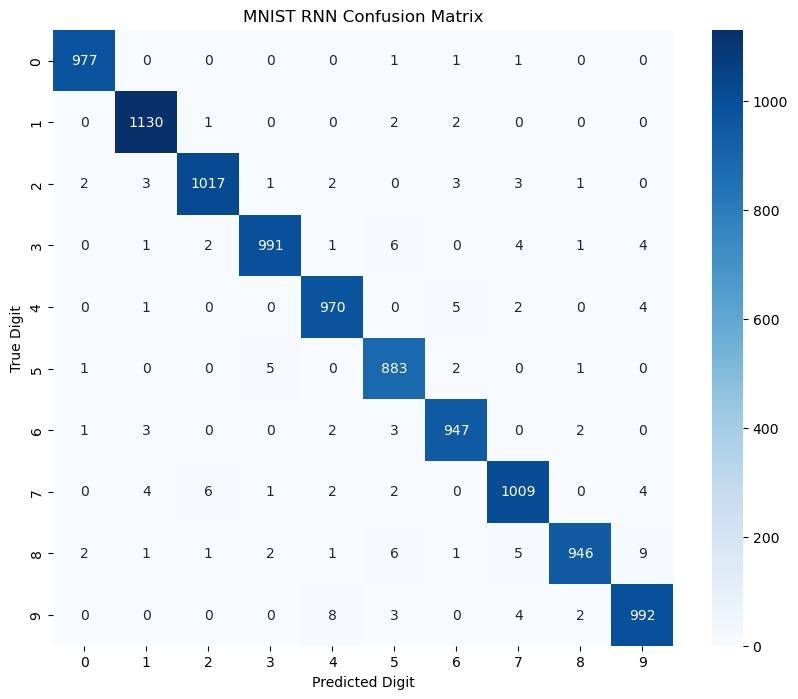

In [28]:
# torch.max() function returns two separate tensors
# The Maximum Values: The actual highest confidence scores found.
# The Indices: The column position where those highest values were found. Because our columns are ordered from 0 to 9, the index matches the predicted digit exactly.

from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    correct_vals = 0
    tot_vals = 0

    for Xb, yb in test_loader:
        Xb = Xb.squeeze(1).to(device)
        yb = yb.to(device)

        outputs = model(Xb)
        _, predicted = torch.max(outputs, dim=1) # dim=1 tells PyTorch to look across the rows (comparing the 10 digit scores for a single image)
        
        tot_vals += yb.size(0)
        correct_vals += ( predicted == yb ).sum().item()

        # Extracting values from GPU/Tensors and append them to your lists
        # .cpu().numpy() moves the data off the GPU so Scikit-Learn can read it
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

    print(f"accuracy = {correct_vals/tot_vals*100}")

print("accuracy_score:", accuracy_score(y_true, y_pred))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(range(10)),
    yticklabels=list(range(10)),
)
plt.title("MNIST RNN Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()

## Build CNN

In [31]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(

            # 1st layer
            nn.Conv2d(1,32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 2nd layer
            nn.Conv2d(32,64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            
        )

        # fully connected layer
        self.fc_layers = nn.Sequential(
            nn.Linear(7*7*64, 128),
            nn.ReLU(),
            # output
            nn.Linear(128,10)
        )

    # forward prop
    def forward(self,x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # flatten
        x = self.fc_layers(x)
        
        return x    

In [35]:
model_cnn = CNN()
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(model_cnn.parameters())

## Train the CNN

In [36]:
epochs = 10

for epoch in range(epochs):
    model_cnn.train()
    
    epoch_training_loss = 0.0

    for images, labels in train_loader:
        optimizer_cnn.zero_grad()
        
        output = model_cnn.forward(images) # FP
        loss = criterion(output, labels)  # loss fnx
        loss.backward() # BP
        optimizer_cnn.step()  # update params

        epoch_training_loss += loss.item()

    print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(train_loader)}")
        

epoch=1/10 & loss=0.12379094927575686
epoch=2/10 & loss=0.03954141786603604
epoch=3/10 & loss=0.02727489754807102
epoch=4/10 & loss=0.019435351938021983
epoch=5/10 & loss=0.016514327781672253
epoch=6/10 & loss=0.013553407553202496
epoch=7/10 & loss=0.010410786979512936
epoch=8/10 & loss=0.009431244758058281
epoch=9/10 & loss=0.0075891483593250415
epoch=10/10 & loss=0.007834278012394082


## Evalation CNN

Accuracy = 99.09
Accuracy_score: 0.9909


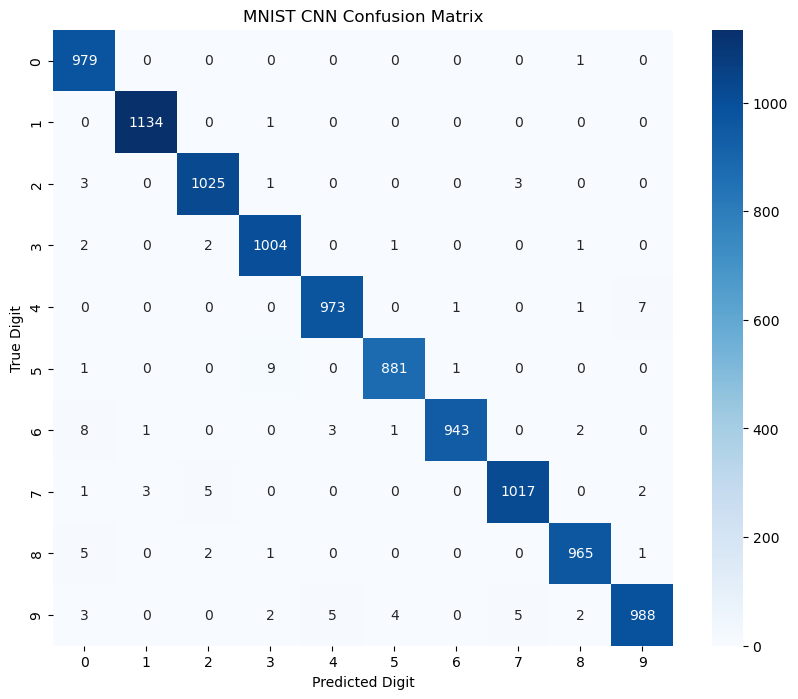

In [42]:
# Evaluate our CNN

from sklearn.metrics import accuracy_score, confusion_matrix

model_cnn.eval()

y_true = []
y_pred = []

correct_labels = 0
total_labels = 0

with torch.no_grad():
    
    for images, labels in test_loader:
        outputs = model_cnn.forward(images)
        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print(f"Accuracy = {correct_labels/total_labels * 100}")
print("Accuracy_score:", accuracy_score(y_true, y_pred))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(range(10)),
    yticklabels=list(range(10)),
)
plt.title("MNIST CNN Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()